In [114]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import glob, os, re, datetime
import matplotlib.dates as mdates

In [16]:
# parameters
sampling_rate = 1000 #Hz
num_samples = 2**14 #16 s per file

### do correlation with drive for charge measurement
plot_drive_correlation = True
f0 = 30 ## Hz, estimate of resonance frequency used for estimating phase shift in correlation
num_corr_samples = int(0.5 * sampling_rate/f0) ## number of samples in a half period 
channel_to_correlate = 'Y' ## channel to correlate with drive signal

In [54]:
# directories
data_dir = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425'
files = glob.glob(data_dir + '/*.npz')
sorted_files = sorted(files, key=lambda x: int(re.search(r'(\d+)\.npz$', os.path.basename(x)).group(1)))

print('Files found: ',len(sorted_files))
for f in sorted_files:
    print(f)


Files found:  77
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_132931.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_132953.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_133015.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_133037.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_133058.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfer_func_28.600Hz_2.000V_4.21e-07bar_133120.npz
/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250425/baseline_transfe

In [21]:
with np.load(sorted_files[0]) as data:
    print(data.files)

['data', 'Fs', 'noise_playback_freq', 'synth_amplitude', 'pressure_data']


In [24]:
with np.load(filename) as d:
    print(d['data'].shape)

(1, 16384, 4)


In [64]:
def compute_psd_and_correlation_from_file(
    filename,
    sampling_rate,
    num_samples,
    ch_names,
    num_corr_samples,
    roi=(5,8)
):
    npz  = np.load(filename)
    arr  = npz['data'][0]

    y_ch     = ch_names.index('Y')
    drive_ch = ch_names.index('Drive')

    f,   Pyy = sp.welch(arr[:, y_ch],     fs=sampling_rate, nperseg=num_samples)
    _,   Pdd = sp.welch(arr[:, drive_ch], fs=sampling_rate, nperseg=num_samples)

    time_val = int(re.search(r'_(\d+)\.npz$', os.path.basename(filename)).group(1))

    corr = sp.correlate(
      arr[:, y_ch],
      arr[:-num_corr_samples, drive_ch],
      mode='valid'
    )
    start, end = roi
    subwin     = corr[start:end]
    max_corr   = subwin[np.argmax(subwin)]

    return {'Y': Pyy, 'Drive': Pdd}, f, time_val, max_corr

In [67]:
psd_dicts      = []
freqs_list     = []
file_times     = []
max_psd_freq   = []
max_psd_amp    = []
max_corr_list  = []

ch_names         = ['X','Y','Sum','Drive']

for filename in sorted_files:
    psd_dict, freqs, time_val, max_corr = \
        compute_psd_and_correlation_from_file(
            filename,
            sampling_rate,
            num_samples,
            ch_names,
            num_corr_samples,
            roi=(5,8)
        )

    psd_dicts.append(psd_dict)
    freqs_list.append(freqs)
    file_times.append(time_val)

    # PSD peaks
    peak_idx = np.argmax(psd_dict['Drive'])
    max_psd_freq.append(freqs[peak_idx])
    max_psd_amp.append(psd_dict['Y'][peak_idx])

    # Correlation peak
    max_corr_list.append(max_corr)

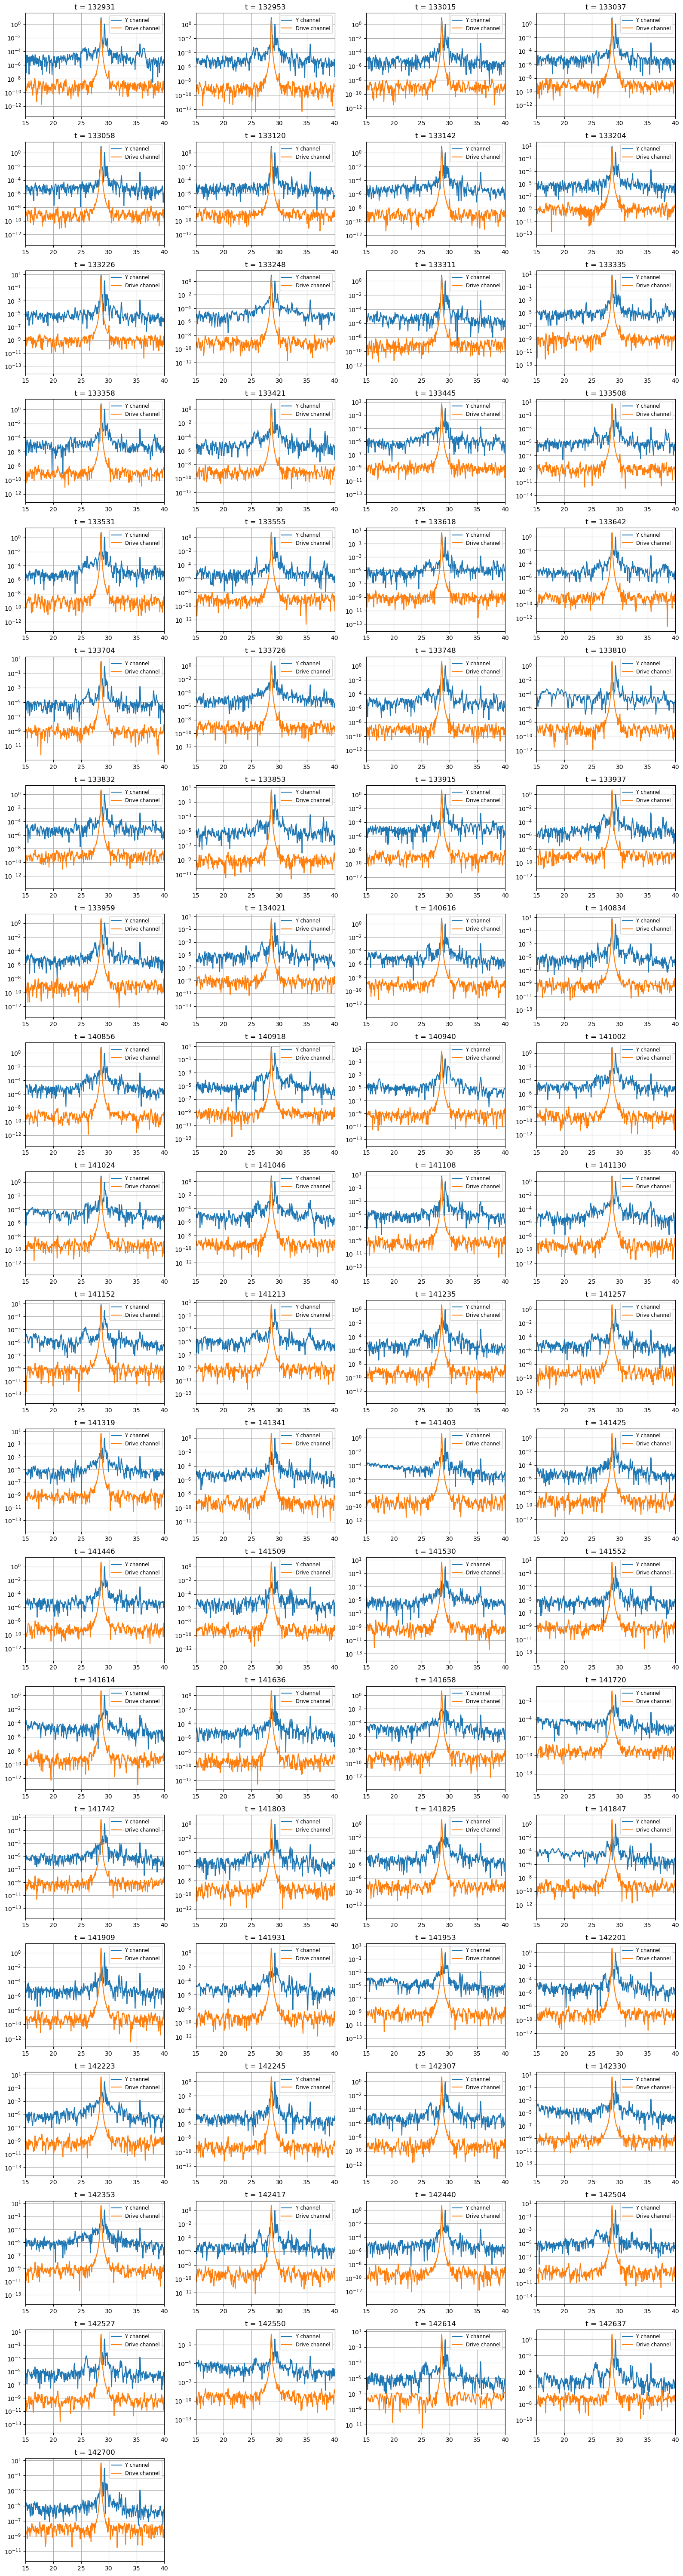

In [69]:
n = len(psd_dicts)
n_cols = 4
n_rows = int(n_files / n_cols) + 1

plt.figure(figsize=(4*n_cols, 3*n_rows))

for idx, (psd, freqs, tval) in enumerate(zip(psd_dicts, freqs_list, file_times), start=1):
    plt.subplot(n_rows, n_cols, idx)
    plt.semilogy(freqs, psd['Y'],    label='Y channel')
    plt.semilogy(freqs, psd['Drive'],label='Drive channel')
    plt.xlim(15, 40)
    plt.title(f"t = {tval}")
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

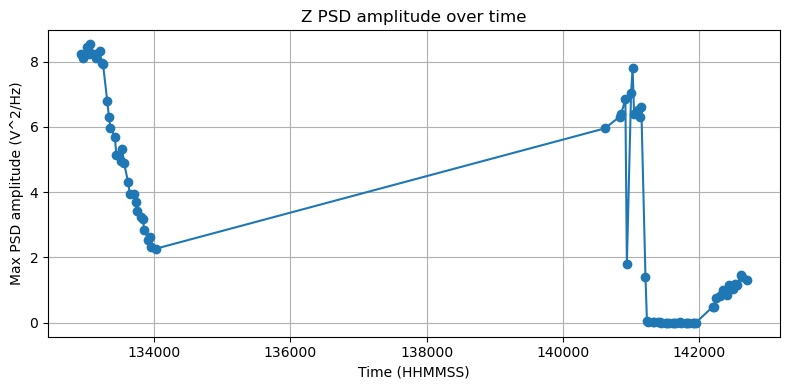

In [59]:
plt.figure(figsize=(8,4))
plt.plot(file_times, max_psd_amp, marker='o', linestyle='-')
plt.xlabel("Time (HHMMSS)")
plt.ylabel("Max PSD amplitude (V^2/Hz)")
plt.title("Z PSD amplitude over time")
plt.grid(True)
plt.tight_layout()
plt.show()

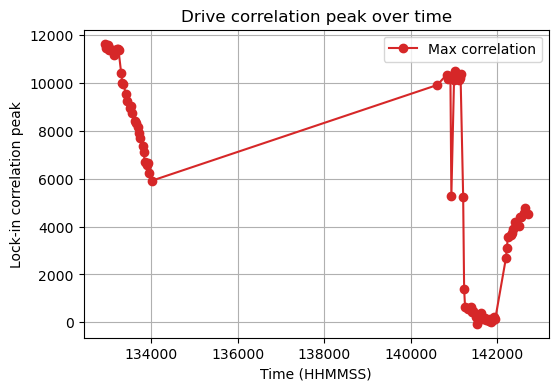

In [70]:
plt.figure(figsize=(6,4))
plt.plot(file_times, max_corr_list, 'o-', color='C3', label='Max correlation')
plt.xlabel("Time (HHMMSS)")
plt.ylabel("Lock-in correlation peak")
plt.title("Drive correlation peak over time")
plt.legend()
plt.grid()

plt.show()

In [111]:
threshold = 140000 
exclude_time = 140940

phases = [os.path.basename(fn).split('_')[0]
              for fn in sorted_files[:len(file_times)]]
info = list(zip(
    sorted_files,
    file_times,
    max_psd_amp,
    max_corr_list,
    phases
))
# keep only those with file_time > threshold
filtered = [inf for inf in info if inf[1] > threshold and inf[1] != exclude_time]


_, f_times, f_psd_amp, f_corr, f_phases = zip(*filtered)


transitions = []
## find transitions in phase
# prev = f_phases[0]
# for t, ph in zip(f_times, f_phases):
#     if ph != prev:
#         transitions.append((t, ph))
#         prev = ph

## find transitions in right before phase change
for i in range(1, len(f_phases)):
    if f_phases[i] != f_phases[i-1]:
        transitions.append((f_times[i-1], f_phases[i]))


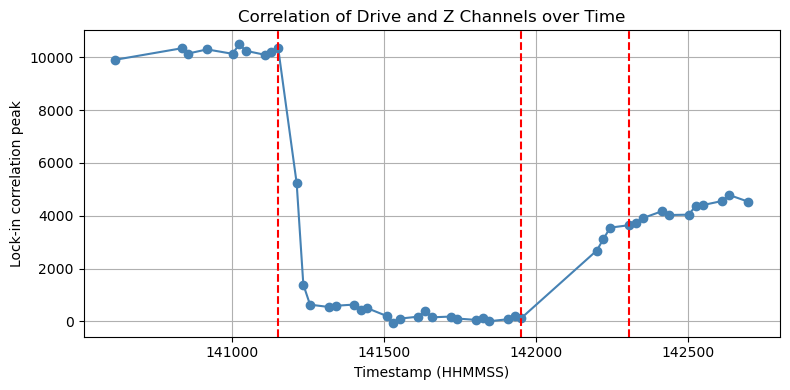

In [126]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f_times, f_corr, 'o-', color='steelblue', label='Max correlation')
for t, ph in transitions:
    ax.axvline(t, color='red', linestyle='--')
    # ax.text(t, ax.get_ylim()[1], ph, rotation=90)
ax.set_xlabel("Timestamp (HHMMSS)")
ax.set_ylabel("Lock-in correlation peak")
ax.set_title("Correlation of Drive and Z Channels over Time")
ax.grid(True)
#ax.legend()
plt.tight_layout()

plt.show()

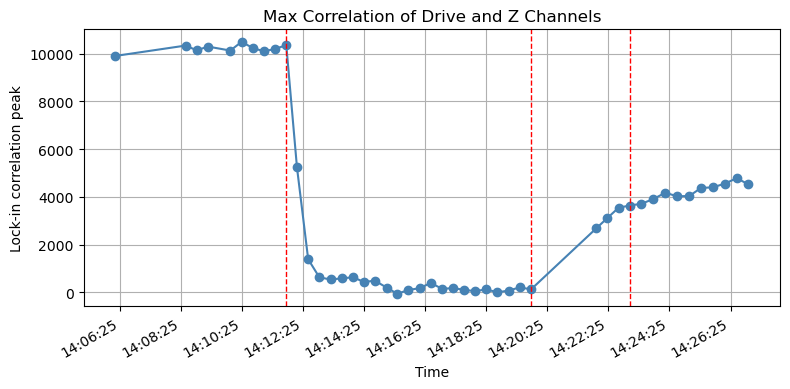

In [ ]:
# build datetime objects
times_dt = [
    datetime.datetime.strptime(f"{t:06d}", "%H%M%S")
    for t in f_times
]

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(times_dt, f_corr, 'o-', color='steelblue', label='Max correlation')

# vertical phase lines (also convert to datetime)
for t_int, ph in transitions:
    t_dt = datetime.datetime.strptime(f"{t_int:06d}", "%H%M%S")
    ax.axvline(t_dt, color='red', linestyle='--', linewidth=1)
    y_max = ax.get_ylim()[1]
    #ax.text(t_dt, y_max, ph, rotation=90, verticalalignment='bottom', fontsize=8)


ax.xaxis.set_major_locator(mdates.SecondLocator(interval=120))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

ax.set_xlabel("Time (HH:MM:SS)")
ax.set_ylabel("Lock-in correlation peak")
ax.set_title("Max Correlation of Drive and Z Channels")
ax.grid(True)
plt.tight_layout()
plt.show()

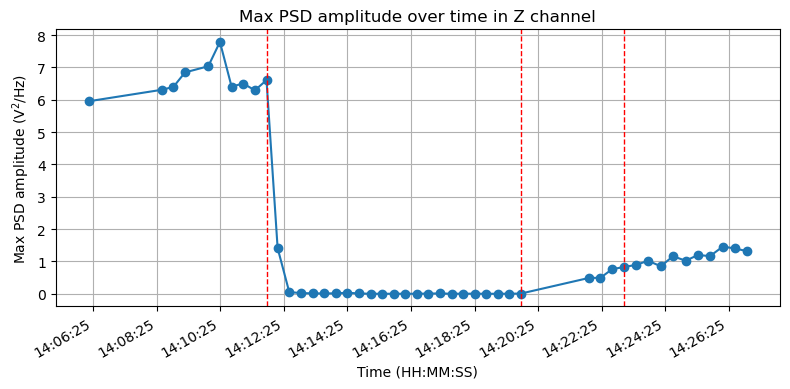

In [128]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(times_dt, f_psd_amp, 'o-', label='Z PSD peak')

# vertical phase lines (also convert to datetime)
for t_int, ph in transitions:
    t_dt = datetime.datetime.strptime(f"{t_int:06d}", "%H%M%S")
    ax.axvline(t_dt, color='red', linestyle='--', linewidth=1)
    y_max = ax.get_ylim()[1]
    #ax.text(t_dt, y_max, ph, rotation=90, verticalalignment='bottom', fontsize=8)


ax.xaxis.set_major_locator(mdates.SecondLocator(interval=120))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()


# for t, ph in transitions:
#     ax.axvline(t, color = 'red', linestyle='--')
#     #ax.text(t, ax.get_ylim()[1], ph, rotation=90, color='red')
ax.set_xlabel("Time (HH:MM:SS)")
ax.set_ylabel("Max PSD amplitude (V$^2$/Hz)")
ax.set_title("Max PSD amplitude over time in Z channel")
ax.grid(True)
#ax.legend()
plt.tight_layout()

In [99]:
print(max_corr_list)

[np.float64(11626.668404900778), np.float64(11433.171620868176), np.float64(11573.905915822006), np.float64(11384.605865320174), np.float64(11412.237197018263), np.float64(11362.615301425634), np.float64(11158.88084560238), np.float64(11426.118064103754), np.float64(11418.9770524416), np.float64(11361.93219573922), np.float64(10387.684910816119), np.float64(10008.568046318655), np.float64(9926.214949072208), np.float64(9535.540755070053), np.float64(9250.004998316523), np.float64(8957.397181994702), np.float64(9034.911824635688), np.float64(8756.582698999075), np.float64(8400.713128866775), np.float64(8329.643993501784), np.float64(8161.236736028445), np.float64(7899.929417211214), np.float64(7701.165501973032), np.float64(7346.666039638146), np.float64(7088.985415707737), np.float64(6696.1341985047475), np.float64(6584.159289010895), np.float64(6630.9296516051345), np.float64(6237.405783155953), np.float64(5913.362617650816), np.float64(9905.85640911596), np.float64(10340.011716687866

In [100]:
print(max_psd_amp)

[np.float64(8.22831637232046), np.float64(8.106345349915735), np.float64(8.454911891822134), np.float64(8.21727775459965), np.float64(8.530194409010566), np.float64(8.216743267915993), np.float64(8.103302678182255), np.float64(8.330841088355728), np.float64(7.956114895840773), np.float64(7.922306010360925), np.float64(6.780632577574972), np.float64(6.30497551745437), np.float64(5.974006508268751), np.float64(5.694042914582956), np.float64(5.145372085344953), np.float64(4.970296782496977), np.float64(5.322055286728484), np.float64(4.907438277940518), np.float64(4.297186965379454), np.float64(3.934968508451802), np.float64(3.9377277476307486), np.float64(3.698277732372023), np.float64(3.422980284455606), np.float64(3.2474902213371575), np.float64(3.1811572208479584), np.float64(2.8467967084151593), np.float64(2.5390915693910983), np.float64(2.6132875758141547), np.float64(2.321822132826108), np.float64(2.2676007163144205), np.float64(5.953729931304886), np.float64(6.308420646014921), np.